# 보스턴집값데이터 회귀분석(라쏘, 릿지, 엘라스틱넷)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("https://raw.githubusercontent.com/haram4th/ADsP/main/01%EB%B3%B4%EC%8A%A4%ED%84%B4%EC%A7%91%EA%B0%92%EB%8D%B0%EC%9D%B4%ED%84%B0.csv")

In [ ]:
[01] CRIM 자치시(town) 별 1인당 범죄율
[02] ZN 25,000 평방피트를 초과하는 거주지역의 비율
[03] INDUS 비소매상업지역이 점유하고 있는 토지의 비율
[04] CHAS 찰스강에 대한 더미변수(강의 경계에 위치한 경우는 1, 아니면 0)
[05] NOX 10ppm 당 농축 일산화질소
[06] RM 주택 1가구당 평균 방의 개수
[07] AGE 1940년 이전에 건축된 소유주택의 비율
[08] DIS 5개의 보스턴 직업센터까지의 접근성 지수
[09] RAD 방사형 도로까지의 접근성 지수
[10] TAX 10,000 달러 당 재산세율
[11] PTRATIO 자치시(town)별 학생/교사 비율
[12] B 1000(Bk-0.63)^2, 여기서 Bk는 자치시별 흑인의 비율을 말함.
[13] LSTAT 모집단의 하위계층의 비율(%)
[14] MEDV 본인 소유의 주택가격(중앙값) (단위: $1,000)

In [4]:
data.head()

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   범죄율           506 non-null    float64
 1   25,000평방피트초과  506 non-null    float64
 2   비소매상업지역비율     506 non-null    float64
 3   찰스강경계         506 non-null    int64  
 4   농축 일산화질소      506 non-null    float64
 5   가구당평균방수       506 non-null    float64
 6   1940년이전건축비율   506 non-null    float64
 7   직업센터접근성       506 non-null    float64
 8   도로접근성         506 non-null    int64  
 9   재산세율          506 non-null    float64
 10  학생/교사비율       506 non-null    float64
 11  흑인비율          506 non-null    float64
 12  하위계층비율        506 non-null    float64
 13  주택가격          506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [7]:
outlier = data.describe()
outlier

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [8]:
outlier.loc['75%'] + (1.5*(outlier.loc['75%'] - outlier.loc['25%']))

범죄율                9.069639
25,000평방피트초과      31.250000
비소매상업지역비율         37.465000
찰스강경계              0.000000
농축 일산화질소           0.886500
가구당평균방수            7.730500
1940년이전건축비율      167.650000
직업센터접근성            9.820800
도로접근성             54.000000
재산세율            1246.500000
학생/교사비율           24.400000
흑인비율             427.496250
하위계층비율            31.962500
주택가격              36.962500
dtype: float64

In [9]:
outlier.loc['25%'] - (1.5*(outlier.loc['75%'] - outlier.loc['25%']))

범죄율              -5.310511
25,000평방피트초과    -18.750000
비소매상업지역비율       -14.175000
찰스강경계             0.000000
농축 일산화질소          0.186500
가구당평균방수           4.778500
1940년이전건축비율     -28.550000
직업센터접근성          -2.532200
도로접근성           -26.000000
재산세율           -301.500000
학생/교사비율          13.200000
흑인비율            344.106250
하위계층비율           -8.057500
주택가격              5.062500
dtype: float64

In [28]:
data[data['범죄율'] > 9.069639].sort_values(by='범죄율')

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격


In [27]:
data['범죄율'] = data['범죄율'].apply(lambda x: 9.069639 if x > 9.069639 else x)

In [30]:
data[data['25,000평방피트초과'] > 31.250000].sort_values(by='25,000평방피트초과')

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격


In [29]:
data['25,000평방피트초과'] = data['25,000평방피트초과'].apply(lambda x: 31.250000 if x > 31.250000 else x)

In [36]:
data[data['가구당평균방수'] > 7.730500].sort_values(by='가구당평균방수')

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격


In [31]:
data['가구당평균방수'] = data['가구당평균방수'].apply(lambda x: 7.730500 if x > 7.730500 else x)

In [38]:
data[data['가구당평균방수'] < 4.778500].sort_values(by='가구당평균방수')

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격


In [37]:
data['가구당평균방수'] = data['가구당평균방수'].apply(lambda x: 4.778500 if x < 4.778500 else x)

In [40]:
data[data['직업센터접근성'] > 9.820800].sort_values(by='직업센터접근성')

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격


In [39]:
data['직업센터접근성'] = data['직업센터접근성'].apply(lambda x: 9.820800 if x > 9.820800 else x)

In [42]:
data[data['학생/교사비율'] < 13.200000].sort_values(by='학생/교사비율')

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격


In [41]:
data['학생/교사비율'] = data['학생/교사비율'].apply(lambda x: 13.200000 if x < 13.200000 else x)

In [44]:
data[data['흑인비율'] < 344.106250].sort_values(by='흑인비율')

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격


In [43]:
data['흑인비율'] = data['흑인비율'].apply(lambda x: 344.106250 if x < 344.106250 else x)

In [46]:
data[data['하위계층비율'] > 31.962500].sort_values(by='하위계층비율')

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격


In [45]:
data['하위계층비율'] = data['하위계층비율'].apply(lambda x: 31.962500 if x > 31.962500 else x)

In [48]:
data[data['주택가격'] > 36.962500].sort_values(by='주택가격')

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격


In [47]:
data['주택가격'] = data['주택가격'].apply(lambda x: 36.962500 if x > 36.962500 else x)

In [50]:
data[data['주택가격'] < 5.062500].sort_values(by='주택가격')

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격


In [49]:
data['주택가격'] = data['주택가격'].apply(lambda x: 5.062500 if x < 5.062500 else x)

In [51]:
data

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격
0,0.00632,18.0,2.31,0,0.538,4.7785,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,4.7785,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,4.7785,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,4.7785,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,4.7785,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,4.7785,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,4.7785,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,4.7785,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,4.7785,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [53]:
data.corr(numeric_only=True)

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격
범죄율,1.000000,-0.370213,0.629315,-0.030748,0.663412,NaN,0.518951,-0.555054,0.926977,0.870686,0.416269,-0.436156,0.592587,-0.538589
"25,000평방피트초과",-0.370213,1.000000,-0.584079,-0.038059,-0.549670,NaN,-0.583149,0.681019,-0.344043,-0.383860,-0.432409,0.236768,-0.448131,0.428126
비소매상업지역비율,0.629315,-0.584079,1.000000,0.062938,0.763651,NaN,0.644779,-0.713079,0.595129,0.720760,0.382359,-0.417485,0.608158,-0.561174
찰스강경계,-0.030748,-0.038059,0.062938,1.000000,0.091203,NaN,0.086518,-0.099435,-0.007368,-0.035587,-0.123763,-0.011069,-0.053288,0.146061
농축 일산화질소,0.663412,-0.549670,0.763651,0.091203,1.000000,NaN,0.731470,-0.775934,0.611441,0.668023,0.190159,-0.427034,0.595619,-0.506505
가구당평균방수,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1940년이전건축비율,0.518951,-0.583149,0.644779,0.086518,0.731470,NaN,1.000000,-0.753333,0.456022,0.506456,0.263355,-0.307560,0.606711,-0.458662
직업센터접근성,-0.555054,0.681019,-0.713079,-0.099435,-0.775934,NaN,-0.753333,1.000000,-0.500007,-0.540200,-0.238556,0.311406,-0.502644,0.333079
도로접근성,0.926977,-0.344043,0.595129,-0.007368,0.611441,NaN,0.456022,-0.500007,1.000000,0.910228,0.466698,-0.392793,0.489186,-0.452679
재산세율,0.870686,-0.383860,0.720760,-0.035587,0.668023,NaN,0.506456,-0.540200,0.910228,1.000000,0.462693,-0.433288,0.545598,-0.543545


C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51396 (\N{HANGUL SYLLABLE JOE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\seaborn\utils.py:61: UserWarn

<Axes: >

C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 51396 (\N{HANGUL SYLLABLE JOE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\5-25\miniforge3\envs\finte

C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51396 (\N{HANGUL SYLLABLE JOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\5-25\miniforge3\envs\fintech\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BAN

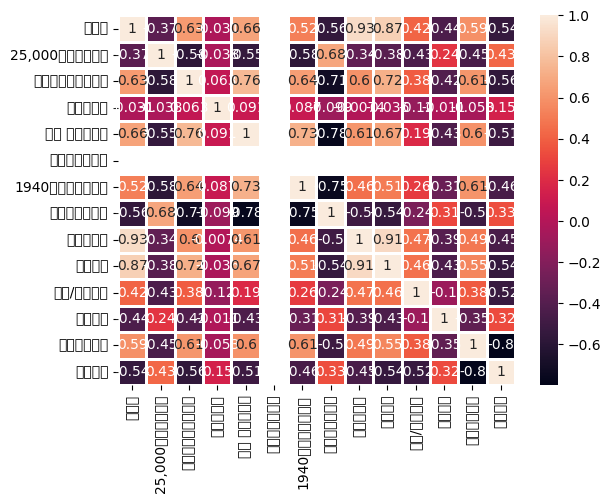

In [52]:
sns.heatmap(data.corr(numeric_only=True), annot=True, linewidth=1)